In [1]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp
import heterostructure_models.dot_3d as d3
import heterostructure_models.dot_2d as d2
import solvers
from matplotlib.colors import Normalize


No alloy disorder, tight-binding models

Norm v0: 0.9999999999999999
Norm v1: 0.9999999999999999
Dipolar matrix elements
<v0 | x | v0 > = -0.14
<v1 | x | v1 > = -0.14
<v0 | x | v1 > = -0.00
<v0 | y | v0 > = -0.38
<v1 | y | v1 > = -0.38
<v0 | y | v1 > = -0.00
<v0 | z | v0 > = 6.52
<v1 | z | v1 > = 6.66
<v0 | z | v1 > = 0.00


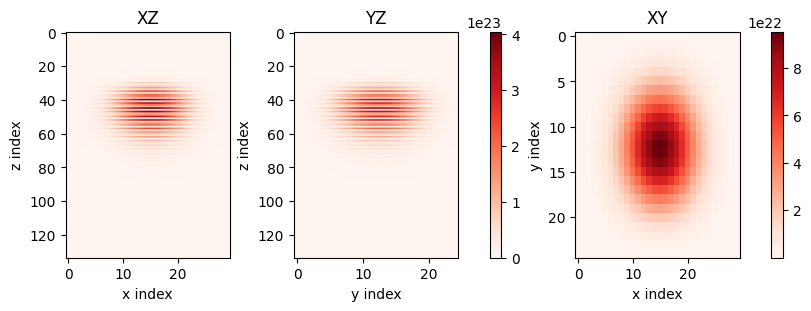

In [2]:
# Sharp vertical profile, so we see the impact of a step on the valley splitting
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', nx=30, dx_unit_cells=4)
d3model = d3.Dot3D(step_model=d2d, dy_unit_cells=4, ny=25)
lat3d = d3model.effective_lattice

model_tb = solvers.TwoBand_3D(
    effective_lattice = lat3d, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d3model.dx_nm,
    dy_nm = d3model.dy_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_3D_matrix_from_vector(v0)
v1 = model_tb.wf_3D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

# Dipolar matrix elements
x01 = model_tb.x01_nm
x00 = model_tb.x00_nm
x11 = model_tb.x11_nm

y01 = model_tb.y01_nm
y00 = model_tb.y00_nm
y11 = model_tb.y11_nm

z01 = model_tb.z01_nm
z00 = model_tb.z00_nm
z11 = model_tb.z11_nm

print('Dipolar matrix elements')
print(f"<v0 | x | v0 > = {x00:0.2f}")
print(f"<v1 | x | v1 > = {x11:0.2f}")
print(f"<v0 | x | v1 > = {x01:0.2f}")
print(f"<v0 | y | v0 > = {y00:0.2f}")
print(f"<v1 | y | v1 > = {y11:0.2f}")
print(f"<v0 | y | v1 > = {y01:0.2f}")
print(f"<v0 | z | v0 > = {z00:0.2f}")
print(f"<v1 | z | v1 > = {z11:0.2f}")
print(f"<v0 | z | v1 > = {z01:0.2f}")

(nx, ny, nz) = np.shape(density_0)
density_0_xz = np.mean(density_0, axis=1)
density_0_yz = np.mean(density_0, axis=0)
density_0_xy = np.mean(density_0, axis=2)

max_wf = max([np.max(density_0_xz), np.max(density_0_yz), np.max(density_0_xy)])


# Plotting
fig, ax = plt.subplots(1, 3, figsize=(8,3), layout='constrained')

im0 = ax[0].imshow(density_0_xz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
ax[0].set_title('XZ')

im1 = ax[1].imshow(density_0_yz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('YZ')

im2 = ax[2].imshow(density_0_xy.T, cmap="Reds", aspect='auto')
fig.colorbar(im2, ax=ax[2])
ax[2].set_title('XY')

ax[0].set_xlabel("x index")
ax[0].set_ylabel("z index")

ax[1].set_xlabel("y index")
ax[1].set_ylabel("z index")

ax[2].set_xlabel("x index")
ax[2].set_ylabel("y index")

plt.show()



No alloy disorder, effective-mass models

Norm v0: 0.9999999999999998
Norm v1: 1.0000000000000004


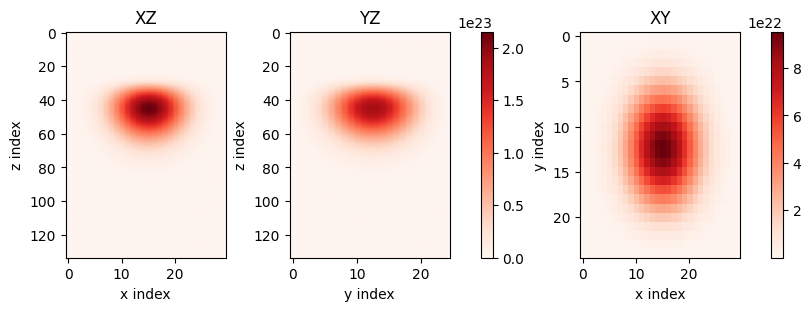

In [3]:
# Sharp vertical profile, so we see the impact of a step on the valley splitting
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', nx=30, dx_unit_cells=4)
d3model = d3.Dot3D(step_model=d2d, dy_unit_cells=4, ny=25)
lat3d = d3model.effective_lattice

model_em = solvers.EffectiveMass_3D(
    effective_lattice = lat3d, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d3model.dx_nm,
    dy_nm = d3model.dy_nm
)

evals, evecs = model_em.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_em.wf_3D_matrix_from_vector(v0)
v1 = model_em.wf_3D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_em.dz * model_em.dx * model_em.dy)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_em.dz * model_em.dx * model_em.dy)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2


(nx, ny, nz) = np.shape(density_0)
density_0_xz = np.mean(density_0, axis=1)
density_0_yz = np.mean(density_0, axis=0)
density_0_xy = np.mean(density_0, axis=2)

max_wf = max([np.max(density_0_xz), np.max(density_0_yz), np.max(density_0_xy)])


# Plotting
fig, ax = plt.subplots(1, 3, figsize=(8,3), layout='constrained')

im0 = ax[0].imshow(density_0_xz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
ax[0].set_title('XZ')

im1 = ax[1].imshow(density_0_yz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('YZ')

im2 = ax[2].imshow(density_0_xy.T, cmap="Reds", aspect='auto')
fig.colorbar(im2, ax=ax[2])
ax[2].set_title('XY')

ax[0].set_xlabel("x index")
ax[0].set_ylabel("z index")

ax[1].set_xlabel("y index")
ax[1].set_ylabel("z index")

ax[2].set_xlabel("x index")
ax[2].set_ylabel("y index")

plt.show()



With alloy disorder

Norm v0: 1.0
Norm v1: 1.0
Dipolar matrix elements
<v0 | x | v0 > = -0.55
<v1 | x | v1 > = -1.76
<v0 | x | v1 > = -0.82
<v0 | y | v0 > = 0.53
<v1 | y | v1 > = 0.59
<v0 | y | v1 > = -1.19
<v0 | z | v0 > = 6.75
<v1 | z | v1 > = 6.75
<v0 | z | v1 > = -0.01


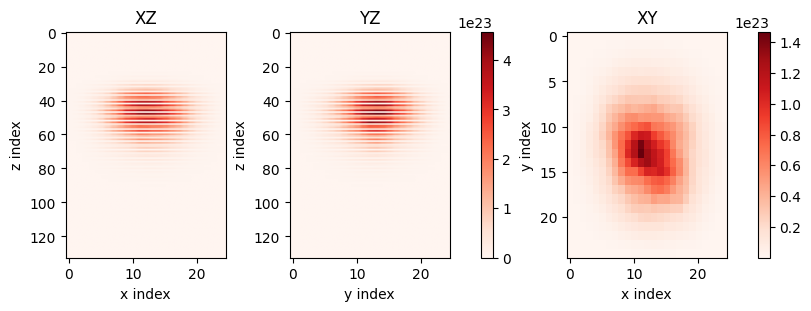

In [4]:
# Add a large amount of Ge to the quantum well to observe disorder effects
prof = vp.VerticalProfile(interface_type='sigmoid', top_cap_width_nm=4, bot_cap_width_nm=4, well_si_concentration=0.95)

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', nx=25, dx_unit_cells=4)
d3model = d3.Dot3D(step_model=d2d, dy_unit_cells=4, ny=25)
lat3d = d3model.generate_random_alloy_lattice()

model_tb = solvers.TwoBand_3D(
    effective_lattice = lat3d, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d3model.dx_nm,
    dy_nm = d3model.dy_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_3D_matrix_from_vector(v0)
v1 = model_tb.wf_3D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

# Used for plotting
alphas_0 = Normalize(clip=True)(density_0)
alphas_1 = Normalize(clip=True)(density_1)

# Dipolar matrix elements
x01 = model_tb.x01_nm
x00 = model_tb.x00_nm
x11 = model_tb.x11_nm

y01 = model_tb.y01_nm
y00 = model_tb.y00_nm
y11 = model_tb.y11_nm

z01 = model_tb.z01_nm
z00 = model_tb.z00_nm
z11 = model_tb.z11_nm

print('Dipolar matrix elements')
print(f"<v0 | x | v0 > = {x00:0.2f}")
print(f"<v1 | x | v1 > = {x11:0.2f}")
print(f"<v0 | x | v1 > = {x01:0.2f}")
print(f"<v0 | y | v0 > = {y00:0.2f}")
print(f"<v1 | y | v1 > = {y11:0.2f}")
print(f"<v0 | y | v1 > = {y01:0.2f}")
print(f"<v0 | z | v0 > = {z00:0.2f}")
print(f"<v1 | z | v1 > = {z11:0.2f}")
print(f"<v0 | z | v1 > = {z01:0.2f}")


(nx, ny, nz) = np.shape(density_0)
density_0_xz = np.mean(density_0, axis=1)
density_0_yz = np.mean(density_0, axis=0)
density_0_xy = np.mean(density_0, axis=2)

max_wf = max([np.max(density_0_xz), np.max(density_0_yz), np.max(density_0_xy)])


# Plotting
fig, ax = plt.subplots(1, 3, figsize=(8,3), layout='constrained')

im0 = ax[0].imshow(density_0_xz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
ax[0].set_title('XZ')

im1 = ax[1].imshow(density_0_yz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('YZ')

im2 = ax[2].imshow(density_0_xy.T, cmap="Reds", aspect='auto')
fig.colorbar(im2, ax=ax[2])
ax[2].set_title('XY')

ax[0].set_xlabel("x index")
ax[0].set_ylabel("z index")

ax[1].set_xlabel("y index")
ax[1].set_ylabel("z index")

ax[2].set_xlabel("x index")
ax[2].set_ylabel("y index")

plt.show()

